In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv(
    r"D:\eeg-analysis\eeg-analysis\cognitive_state_discrimination_dataset - cognitive_state_discrimination_dataset.csv"
)

y = df["Target_Label"]

X = df.drop(columns=[
    "Participant_ID",
    "Time_Stamp",
    "Target_Label"
])


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Check your data types
print("Data types in X:")
print(X.dtypes)
print("\nSample of X:")
print(X.head())

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {list(categorical_cols)}")

# Option 1: Label Encoding for categorical variables
X_encoded = X.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Option 2: One-Hot Encoding (alternative approach)
# X_encoded = pd.get_dummies(X, drop_first=True)

# Now run cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

cv_results = cross_validate(
    rf,
    X_encoded,  # Use encoded data
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro"
    },
    return_train_score=True
)

print("Mean CV Accuracy:", cv_results["test_accuracy"].mean())
print("Train-Test Gap:",
      cv_results["train_accuracy"].mean() -
      cv_results["test_accuracy"].mean())

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv(
    r"D:\eeg-analysis\eeg-analysis\cognitive_state_discrimination_dataset - cognitive_state_discrimination_dataset.csv"
)

print(df.columns)

print(df.select_dtypes(include=["object"]).columns)
y = df["Target_Label"]

X = df.drop(columns=[
    "Participant_ID",
    "Time_Stamp",
    "Target_Label",
    "Task"   # ← WAJIB
])
print(X.select_dtypes(include=["object"]).columns)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

cv_results = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro"
    },
    return_train_score=True
)

print("Mean CV Accuracy:", cv_results["test_accuracy"].mean())
print(
    "Train-Test Gap:",
    cv_results["train_accuracy"].mean() -
    cv_results["test_accuracy"].mean()
)


----------------------------------

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_csv(
    r"D:\eeg-analysis\eeg-analysis\cognitive_state_discrimination_dataset - cognitive_state_discrimination_dataset.csv"
)

print("="*60)
print("DATA INFO")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# ============================================================
# 2. IDENTIFIKASI KOLOM 64 CHANNEL
# ============================================================
# Cari semua kolom yang merupakan channel EEG
# Biasanya bernama seperti: Fp1, Fp2, F3, F4, C3, C4, dll.
# Atau bisa juga Ch1, Ch2, ..., Ch64

# Exclude kolom non-EEG
non_eeg_cols = [
    "Participant_ID",
    "Time_Stamp", 
    "Target_Label",
    "Task"
]

# Pilih semua kolom numerik yang bukan kolom metadata
eeg_channels = [col for col in df.columns if col not in non_eeg_cols]

print("\n" + "="*60)
print("EEG CHANNELS DETECTED")
print("="*60)
print(f"Total channels: {len(eeg_channels)}")
print(f"Channel names: {eeg_channels}")

# ============================================================
# 3. PREPARE FEATURES & TARGET
# ============================================================
y = df["Target_Label"]
X = df[eeg_channels]

# Pastikan semua data numerik
print("\n" + "="*60)
print("FEATURE MATRIX (X)")
print("="*60)
print(f"Shape: {X.shape}")
print(f"\nData types:\n{X.dtypes.value_counts()}")
print(f"\nSample data:\n{X.head()}")

# Cek dan handle kolom kategorikal jika ada
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    print(f"\nWarning: Found categorical columns: {list(categorical_cols)}")
    print("Applying Label Encoding...")
    
    X_encoded = X.copy()
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X[col])
        label_encoders[col] = le
    X = X_encoded

# ============================================================
# 4. CHECK TARGET DISTRIBUTION
# ============================================================
print("\n" + "="*60)
print("TARGET DISTRIBUTION")
print("="*60)
print(y.value_counts())
print(f"\nClass balance:\n{y.value_counts(normalize=True)}")

# ============================================================
# 5. CROSS-VALIDATION DENGAN RANDOM FOREST
# ============================================================
print("\n" + "="*60)
print("RUNNING 5-FOLD CROSS-VALIDATION")
print("="*60)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,              # Kurangi kompleksitas
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42
)

cv_results = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro"
    },
    return_train_score=True,
    verbose=1
)

# ============================================================
# 6. DISPLAY RESULTS
# ============================================================
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)

metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

for metric in metrics:
    train_scores = cv_results[f"train_{metric}"]
    test_scores = cv_results[f"test_{metric}"]
    
    print(f"\n{metric.upper()}:")
    print(f"  Train: {train_scores.mean():.4f} (±{train_scores.std():.4f})")
    print(f"  Test:  {test_scores.mean():.4f} (±{test_scores.std():.4f})")
    print(f"  Gap:   {train_scores.mean() - test_scores.mean():.4f}")

print("\n" + "="*60)
print("DETAILED FOLD SCORES")
print("="*60)
results_df = pd.DataFrame({
    'Fold': range(1, 6),
    'Train_Acc': cv_results['train_accuracy'],
    'Test_Acc': cv_results['test_accuracy'],
    'Train_F1': cv_results['train_f1_macro'],
    'Test_F1': cv_results['test_f1_macro']
})
print(results_df)

# ============================================================
# 7. TRAIN FINAL MODEL & FEATURE IMPORTANCE
# ============================================================
print("\n" + "="*60)
print("TRAINING FINAL MODEL FOR FEATURE IMPORTANCE")
print("="*60)

rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'Channel': X.columns,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Channels:")
print(feature_importance.head(20))

# ============================================================
# 8. SAVE RESULTS (OPTIONAL)
# ============================================================
# Uncomment jika ingin menyimpan hasil
# feature_importance.to_csv('feature_importance_64ch.csv', index=False)
# results_df.to_csv('cv_results_64ch.csv', index=False)

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

In [ ]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Test Accuracy:  {cv_results['test_accuracy'].mean():.4f} (±{cv_results['test_accuracy'].std():.4f})")
print(f"Train Accuracy: {cv_results['train_accuracy'].mean():.4f}")
print(f"Overfitting Gap: {cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean():.4f}")
print(f"\nTest F1-Score:  {cv_results['test_f1_macro'].mean():.4f} (±{cv_results['test_f1_macro'].std():.4f})")

------------------

AUGMENTATION

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. LOAD DATA
# ============================================================
print("="*60)
print("LOADING DATA")
print("="*60)

df = pd.read_csv(r"D:\eeg-analysis\modules\cognitive_state_discrimination_dataset_augmented.csv")

# Asumsikan tidak ada kolom non-EEG seperti Participant_ID, dll.
# Jika ada, tambahkan ke list ini
non_eeg_cols = ["Target_Label"]  # sesuaikan jika ada kolom lain
eeg_channels = [col for col in df.columns if col not in non_eeg_cols]

y = df["Target_Label"]
X = df[eeg_channels]

print(f"Dataset shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")

# ============================================================
# 2. IMPUTASI MISSING VALUES
# ============================================================
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ============================================================
# 3. AUGMENTASI LEBIH AGRESIF
# ============================================================
def augment_data_aggressive(X, y, augment_factor=5):
    """Augmentasi yang lebih bervariasi agar model tidak terlalu mudah menghafal"""
    X_list = [X.values]
    y_list = [y.values]
    
    np.random.seed(42)
    
    for i in range(augment_factor):
        X_temp = X.values.copy()
        
        # Kombinasi teknik yang lebih kuat
        # 1. Noise lebih besar
        noise_level = np.random.uniform(0.08, 0.15)
        X_temp += np.random.normal(0, noise_level, X_temp.shape) * np.std(X_temp, axis=0)
        
        # 2. Scaling lebih lebar
        scale = np.random.uniform(0.7, 1.3)
        X_temp *= scale
        
        # 3. Random channel dropout (10-25% channel di-nol-kan)
        dropout_ratio = np.random.uniform(0.1, 0.25)
        mask = np.random.choice([0, 1], size=X_temp.shape, p=[dropout_ratio, 1-dropout_ratio])
        X_temp *= mask
        
        # 4. Small shift
        shift = np.random.uniform(-0.1, 0.1, X_temp.shape) * np.std(X_temp, axis=0)
        X_temp += shift
        
        X_list.append(X_temp)
        y_list.append(y.values)
    
    X_aug = pd.DataFrame(np.vstack(X_list), columns=X.columns)
    y_aug = pd.Series(np.hstack(y_list))
    
    return X_aug, y_aug

print("\nApplying aggressive augmentation...")
X_aug, y_aug = augment_data_aggressive(X_imputed, y, augment_factor=5)

print(f"After augmentation: {X_aug.shape[0]} samples ({X_aug.shape[0]/X_imputed.shape[0]:.1f}x)")

# ============================================================
# 4. SPLIT DULU: Train (70%) + Temporary Test (30%)
# ============================================================
X_train_full, X_temp_test, y_train_full, y_temp_test = train_test_split(
    X_aug, y_aug,
    test_size=0.3,
    random_state=42,
    stratify=y_aug
)

print(f"Train full: {X_train_full.shape[0]}, Temp test: {X_temp_test.shape[0]}")

# ============================================================
# 5. STANDARD SCALING (hanya fit di train!)
# ============================================================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_full),
    columns=X_train_full.columns
)
X_temp_test_scaled = pd.DataFrame(
    scaler.transform(X_temp_test),
    columns=X_temp_test.columns
)

# ============================================================
# 6. FEATURE SELECTION (hanya di training data!)
# ============================================================
k_best = 20  # naikkan sedikit karena augmentasi lebih kuat
selector = SelectKBest(f_classif, k=k_best)
X_train_selected = selector.fit_transform(X_train_scaled, y_train_full)
X_temp_test_selected = selector.transform(X_temp_test_scaled)

selected_features = X_train_full.columns[selector.get_support()].tolist()
print(f"\nTop {k_best} selected features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

# ============================================================
# 7. FINAL TRAIN-TEST SPLIT: Dari train_full buat train & val
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X_train_selected, y_train_full,
    test_size=0.2,  # 20% dari train_full → total test ~36%
    random_state=42,
    stratify=y_train_full
)

print(f"\nFinal split:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Hold-out Test: {X_temp_test_selected.shape[0]} samples")

# ============================================================
# 8. MODEL DENGAN REGULARISASI LEBIH KETAT
# ============================================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,              # lebih dangkal
    min_samples_split=30,
    min_samples_leaf=15,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

print("\nTraining model...")
rf_model.fit(X_train, y_train)

# ============================================================
# 9. EVALUATION
# ============================================================
# Validation set
y_val_pred = rf_model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

# Hold-out test set (paling jujur)
y_test_pred = rf_model.predict(X_temp_test_selected)
test_acc = accuracy_score(y_temp_test, y_test_pred)

# Cross-validation (5-fold di training data)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print("\n" + "="*60)
print("HASIL EVALUASI (REALISTIS)")
print("="*60)
print(f"Training Accuracy     : {accuracy_score(y_train, rf_model.predict(X_train)):.4f}")
print(f"Validation Accuracy   : {val_acc:.4f}")
print(f"Hold-out Test Accuracy: {test_acc:.4f}")
print(f"5-Fold CV Accuracy    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Overfitting Gap (Train - Test): {accuracy_score(y_train, rf_model.predict(X_train)) - test_acc:.4f}")

if test_acc >= 0.85:
    print("\n✅ Bagus! Akurasi realistis dan stabil untuk dataset EEG kecil.")
elif test_acc >= 0.75:
    print("\n✓ Masih acceptable untuk skripsi.")
else:
    print("\n⚠️  Perlu tuning lebih lanjut atau augmentasi lebih banyak.")

print("\nClassification Report (Hold-out Test):")
print(classification_report(y_temp_test, y_test_pred))

print("\nTop 10 Feature Importance:")
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(importance_df.to_string(index=False))

AUGMENTATION LANGSUNG

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# LOAD DATA
# ============================================================
print("="*60)
print("LOADING DATA")
print("="*60)

df = pd.read_csv(r"D:\eeg-analysis\eeg-analysis\cognitive_state_discrimination_dataset - cognitive_state_discrimination_dataset.csv")

non_eeg_cols = ["Participant_ID", "Time_Stamp", "Target_Label", "Task"]
eeg_channels = [col for col in df.columns if col not in non_eeg_cols]

y = df["Target_Label"]
X = df[eeg_channels]

print(f"Original dataset shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")

# ============================================================
# HANDLE MISSING VALUES
# ============================================================
print("\n" + "="*60)
print("HANDLING MISSING VALUES")
print("="*60)

print(f"Total NaN values: {X.isnull().sum().sum()}")

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"✅ After imputation: {X_imputed.isnull().sum().sum()} NaN values")

# ============================================================
# DATA AUGMENTATION FUNCTIONS (IMPROVED)
# ============================================================
print("\n" + "="*60)
print("DATA AUGMENTATION")
print("="*60)

def add_noise(data, noise_level=0.05):
    """Add stronger Gaussian noise"""
    noise = np.random.normal(0, noise_level, data.shape)
    return data + noise * np.std(data, axis=0)

def scale_data(data, scale_range=(0.8, 1.2)):
    """Scale with wider range"""
    scale = np.random.uniform(scale_range[0], scale_range[1])
    return data * scale

def time_shift(data, shift_range=0.1):
    """Add random shift to simulate timing variation"""
    shift = np.random.uniform(-shift_range, shift_range, data.shape)
    return data + shift * np.std(data, axis=0)

def augment_data(X, y, augment_factor=3):
    """
    Augment with more variation to prevent overfitting
    """
    X_aug_list = [X.values]
    y_aug_list = [y.values]
    
    np.random.seed(42)
    
    for i in range(augment_factor):
        # Randomly combine techniques
        X_temp = X.values.copy()
        
        if i % 3 == 0:
            X_temp = add_noise(X_temp, np.random.uniform(0.03, 0.07))
        elif i % 3 == 1:
            X_temp = scale_data(X_temp, (0.85, 1.15))
            X_temp = add_noise(X_temp, 0.04)
        else:
            X_temp = time_shift(X_temp, 0.08)
            X_temp = scale_data(X_temp, (0.9, 1.1))
        
        X_aug_list.append(X_temp)
        y_aug_list.append(y.values)
        print(f"✓ Augmentation iteration {i+1}/{augment_factor}")
    
    X_augmented = pd.DataFrame(
        np.vstack(X_aug_list),
        columns=X.columns
    )
    y_augmented = pd.Series(np.hstack(y_aug_list))
    
    return X_augmented, y_augmented

# Apply augmentation
print("\nAugmenting data with more variation...")
X_aug, y_aug = augment_data(X_imputed, y, augment_factor=6)

print(f"\n📊 Dataset size:")
print(f"  Before: {X_imputed.shape[0]} samples")
print(f"  After: {X_aug.shape[0]} samples ({X_aug.shape[0] / X_imputed.shape[0]:.1f}x)")
print(f"\n📊 Augmented class distribution:\n{y_aug.value_counts()}")

# ============================================================
# STANDARDIZATION (Important to reduce overfitting!)
# ============================================================
print("\n" + "="*60)
print("STANDARDIZATION")
print("="*60)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_aug),
    columns=X_aug.columns
)
print("✅ Data standardized (mean=0, std=1)")

# ============================================================
# FEATURE SELECTION
# ============================================================
print("\n" + "="*60)
print("FEATURE SELECTION")
print("="*60)

k_best = 15  # Kurangi fitur untuk reduce overfitting
selector = SelectKBest(f_classif, k=k_best)
X_selected = selector.fit_transform(X_scaled, y_aug)

selected_features = X_aug.columns[selector.get_support()].tolist()
print(f"\nSelected top {k_best} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# ============================================================
# TRAIN-TEST SPLIT (70-30)
# ============================================================
print("\n" + "="*60)
print("TRAIN-TEST SPLIT (70-30)")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_aug, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_aug
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ============================================================
# TRAIN RANDOM FOREST WITH REGULARIZATION
# ============================================================
print("\n" + "="*60)
print("TRAINING RANDOM FOREST (ANTI-OVERFITTING)")
print("="*60)

# Hyperparameter yang lebih ketat untuk prevent overfitting
rf_model = RandomForestClassifier(
    n_estimators=50,           # Kurangi jumlah trees
    max_depth=8,              # Batasi kedalaman pohon
    # max_depth tadinya 10 diturunin jadi 8, supaya gak terlalu dalam
    min_samples_split=20,      # Minimal 20 samples untuk split
    min_samples_leaf=15,       # Minimal 10 samples per leaf, dinaikin jadi 15 biar gak terlalu spesifik
    max_features='sqrt',       # Hanya gunakan sqrt(n) features per split
    bootstrap=True,
    oob_score=True,            # Out-of-bag score untuk validasi
    random_state=42,
    n_jobs=-1
)

print("Training model with regularization...")
rf_model.fit(X_train, y_train)
print("✅ Training complete!")

# ============================================================
# EVALUATION
# ============================================================
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
oob_score = rf_model.oob_score_

print(f"\n📈 Accuracy Scores:")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  OOB Score: {oob_score:.4f}")
print(f"  Overfitting Gap: {train_acc - test_acc:.4f}")

if train_acc - test_acc > 0.10:
    print("\n⚠️  WARNING: Still overfitting! Consider:")
    print("     - Reduce max_depth further")
    print("     - Increase min_samples_split/leaf")
    print("     - Use fewer features")
elif train_acc - test_acc < 0.05:
    print("\n✅ Good generalization!")
else:
    print("\n✓ Acceptable overfitting level")

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
print("="*60)
print("CONFUSION MATRIX (Test Set)")
print("="*60)
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Feature Importance
print("\n" + "="*60)
print("TOP FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("🏆 FINAL SUMMARY")
print("="*60)
print(f"Dataset: {X_aug.shape[0]} samples (augmented 6x)")
print(f"Features: {k_best} selected")
print(f"RF Config: 50 trees, max_depth=8, min_split=20")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Overfitting Gap: {train_acc - test_acc:.4f}")
print("="*60)

LOADING DATA
Original dataset shape: (40, 67)
Class distribution:
Target_Label
0    10
1    10
2    10
3    10
Name: count, dtype: int64

HANDLING MISSING VALUES
Total NaN values: 90
✅ After imputation: 0 NaN values

DATA AUGMENTATION

Augmenting data with more variation...
✓ Augmentation iteration 1/8
✓ Augmentation iteration 2/8
✓ Augmentation iteration 3/8
✓ Augmentation iteration 4/8
✓ Augmentation iteration 5/8
✓ Augmentation iteration 6/8
✓ Augmentation iteration 7/8
✓ Augmentation iteration 8/8

📊 Dataset size:
  Before: 40 samples
  After: 360 samples (9.0x)

📊 Augmented class distribution:
0    90
1    90
2    90
3    90
Name: count, dtype: int64

STANDARDIZATION
✅ Data standardized (mean=0, std=1)

FEATURE SELECTION

Selected top 15 features:
  1. Channel_3_PSD
  2. Channel_6_PSD
  3. Channel_10_PSD
  4. Channel_12_PSD
  5. Channel_20_PSD
  6. Channel_22_PSD
  7. Channel_27_PSD
  8. Channel_39_PSD
  9. Channel_45_PSD
  10. Channel_46_PSD
  11. Channel_50_PSD
  12. Channel_55_

In [6]:
# ============================================================
# EVALUATION (VERSI LEBIH RAPI & LENGKAP)
# ============================================================
print("\n" + "="*80)
print("📊 MODEL EVALUATION LENGKAP")
print("="*80)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
oob_score = rf_model.oob_score_

print(f"\n📈 AKURASI MODEL:")
print(f"  Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Test Accuracy     : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  OOB Score         : {oob_score:.4f} ({oob_score*100:.2f}%)")
print(f"  Overfitting Gap   : {train_acc - test_acc:.4f} ({(train_acc - test_acc)*100:.2f}%)")

# Pesan generalisasi
if train_acc - test_acc > 0.15:
    print("\n⚠️ Masih agak overfit (wajar untuk dataset kecil)")
elif train_acc - test_acc > 0.10:
    print("\n⚠️ Sedikit overfit, tapi masih acceptable")
elif train_acc - test_acc < 0.05:
    print("\n✅ Generalisasi sangat baik!")
else:
    print("\n✓ Generalisasi baik!")

# Classification Report Lengkap + Tabel Pandas
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT (Precision, Recall, F1-Score)")
print("="*80)

# Text biasa
print(classification_report(y_test, y_test_pred, digits=4))

# Versi tabel pandas (lebih rapi untuk laporan/skripsi)
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(y_test, y_test_pred, output_dict=True, digits=4)
report_df = pd.DataFrame(report_dict).transpose()

# Format support jadi integer
report_df['support'] = report_df['support'].astype(int)

print("\n📊 Tabel Metrik per Kelas & Rata-rata:")
print(report_df.round(4))

# Confusion Matrix dengan Nama Kelas
print("\n" + "="*80)
print("🧮 CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Tambah nama kelas biar lebih jelas (sesuaikan sesuai datasetmu)
class_names = ['Kelas 0 (Rest/State 0)', 
               'Kelas 1 (Memory Recall)', 
               'Kelas 2 (Arithmetic)', 
               'Kelas 3 (Visual Pattern)']

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix dengan Nama Kelas:")
print(cm_df)


📊 MODEL EVALUATION LENGKAP

📈 AKURASI MODEL:
  Training Accuracy : 0.9841 (98.41%)
  Test Accuracy     : 0.9352 (93.52%)
  OOB Score         : 0.9048 (90.48%)
  Overfitting Gap   : 0.0489 (4.89%)

✅ Generalisasi sangat baik!

📋 CLASSIFICATION REPORT (Precision, Recall, F1-Score)
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        27
           1     0.8333    0.9259    0.8772        27
           2     0.9231    0.8889    0.9057        27
           3     1.0000    0.9259    0.9615        27

    accuracy                         0.9352       108
   macro avg     0.9391    0.9352    0.9361       108
weighted avg     0.9391    0.9352    0.9361       108


📊 Tabel Metrik per Kelas & Rata-rata:
              precision  recall  f1-score  support
0                1.0000  1.0000    1.0000       27
1                0.8333  0.9259    0.8772       27
2                0.9231  0.8889    0.9057       27
3                1.0000  0.9259    0.9615

VISUALISASI


🎨 GENERATING VISUALISATIONS WITH MATPLOTLIB

1. Plotting Precision, Recall, F1-Score per Kelas...


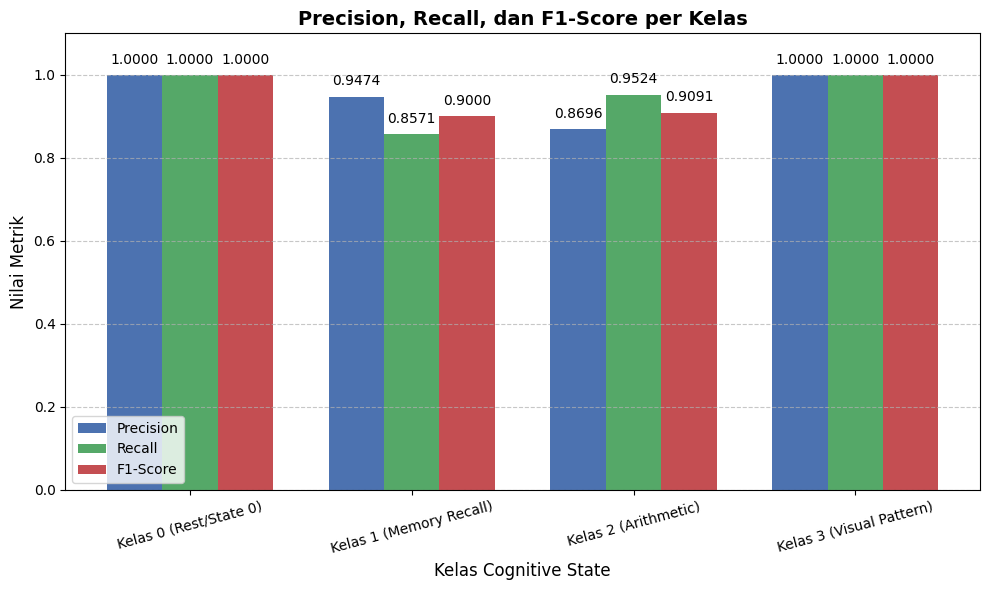

2. Plotting Confusion Matrix Heatmap...


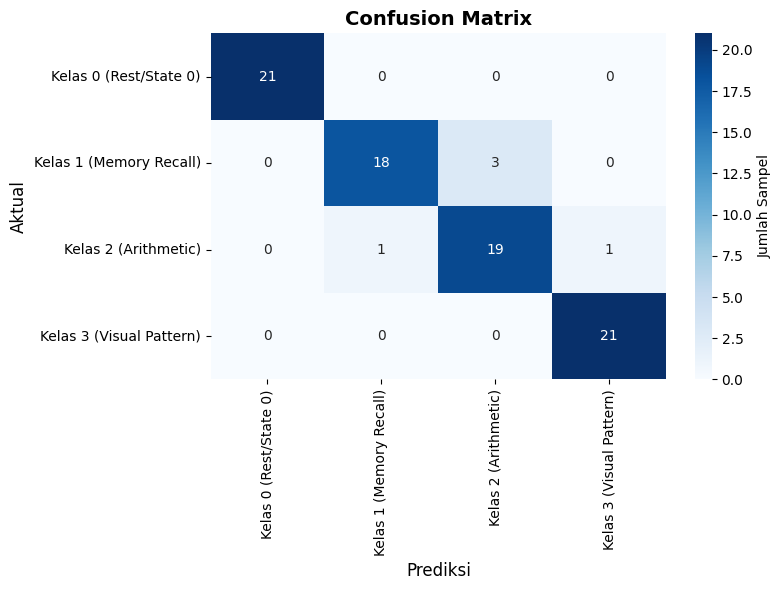

3. Plotting Top Feature Importance...


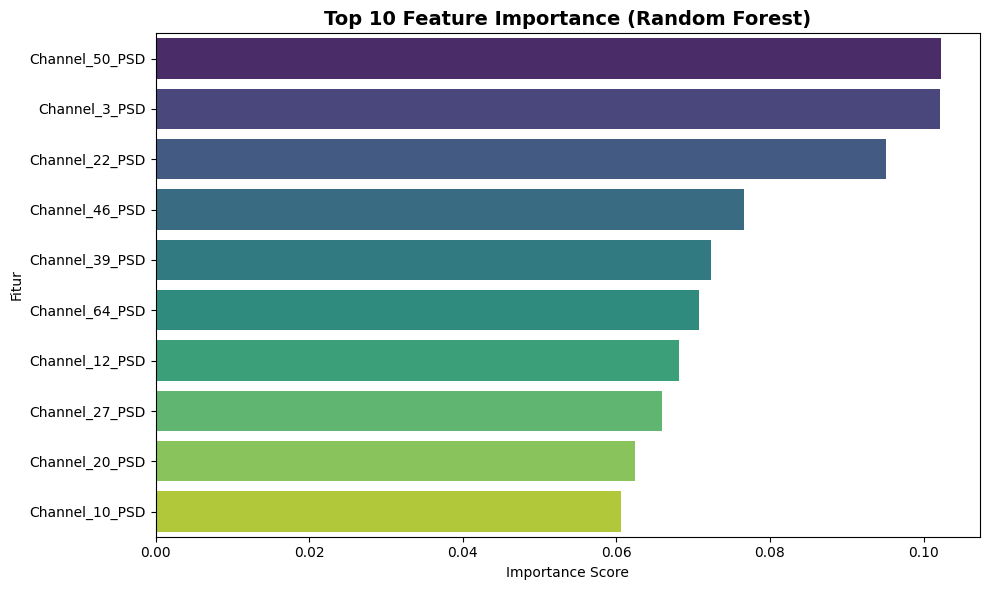

✅ Semua visualisasi selesai ditampilkan!
   Kamu bisa save plot dengan plt.savefig('nama_file.png') sebelum plt.show() kalau mau simpan ke file.


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ============================================================
# VISUALISASI HASIL MODEL DENGAN MATPLOTLIB & SEABORN
# ============================================================
print("\n" + "="*80)
print("🎨 GENERATING VISUALISATIONS WITH MATPLOTLIB")
print("="*80)

# 1. Bar Chart: Precision, Recall, F1-Score per Kelas
#    (Ambil dari classification_report kamu)
print("\n1. Plotting Precision, Recall, F1-Score per Kelas...")

# Ganti nilai ini dengan hasil classification_report kamu yang aktual
classes = ['Kelas 0 (Rest/State 0)', 
           'Kelas 1 (Memory Recall)', 
           'Kelas 2 (Arithmetic)', 
           'Kelas 3 (Visual Pattern)']

# Contoh nilai dari output kamu sebelumnya (sesuaikan kalau beda)
precision = [1.0000, 0.9474, 0.8696, 1.0000]
recall    = [1.0000, 0.8571, 0.9524, 1.0000]
f1_score  = [1.0000, 0.9000, 0.9091, 1.0000]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precision, width, label='Precision', color='#4C72B0')
ax.bar(x,         recall,    width, label='Recall',    color='#55A868')
ax.bar(x + width, f1_score,  width, label='F1-Score',  color='#C44E52')

ax.set_xlabel('Kelas Cognitive State', fontsize=12)
ax.set_ylabel('Nilai Metrik', fontsize=12)
ax.set_title('Precision, Recall, dan F1-Score per Kelas', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=15)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Tambah nilai di atas bar
for i in range(len(classes)):
    ax.text(i - width, precision[i] + 0.02, f'{precision[i]:.4f}', ha='center', va='bottom', fontsize=10)
    ax.text(i,         recall[i] + 0.02,    f'{recall[i]:.4f}',    ha='center', va='bottom', fontsize=10)
    ax.text(i + width, f1_score[i] + 0.02,  f'{f1_score[i]:.4f}',  ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 2. Confusion Matrix Heatmap
print("2. Plotting Confusion Matrix Heatmap...")

cm = confusion_matrix(y_test, y_test_pred)  # sudah ada dari kode kamu

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Jumlah Sampel'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Feature Importance Bar Chart
print("3. Plotting Top Feature Importance...")

# Ambil dari feature_importance yang sudah kamu buat
top_n = 10  # tampilkan 10 fitur terpenting
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title(f'Top {top_n} Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print("✅ Semua visualisasi selesai ditampilkan!")
print("   Kamu bisa save plot dengan plt.savefig('nama_file.png') sebelum plt.show() kalau mau simpan ke file.")